# 2D tracking example



## Imports

In [342]:
import sys
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
from scipy import linalg


### Helpers functions

In [343]:
def plot_trajectory(y, x1, label1, x2=None, label2=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(y[:, 0], y[:, 1], marker="o", label="Measurements", color="red")
    ax.plot(x1[:, 0], x1[:, 1], label=label1, color="blue")
    if x2 is None:
        ax.scatter(x1[0, 0], x1[0, 1], marker="x", color="orange", s=500)
    else:
        ax.plot(x2[:, 0], x2[:, 1], label=label2, color="orange")
    _ = ax.legend()
    _ = ax.set_xlabel("x_1")
    _ = ax.set_ylabel("y_1")


def _atleast2d(*args):
    return tuple(np.atleast_2d(elem) for elem in args)

def generate_ssm(m_0, A, Q, H, R, steps):
    m_0 = np.atleast_1d(m_0)
    A, Q, H, R = _atleast2d(A, Q, H, R)

    M = m_0.shape[-1]
    N = R.shape[-1]
    states = np.empty((steps, M))
    observations = np.empty((steps, N))

    chol_Q = np.linalg.cholesky(Q)
    chol_R = np.linalg.cholesky(R)

    state = m_0
    for i in range(steps):
        state = A @ state + chol_Q @ rd.randn(M)
        states[i, :] = state
        obs = H @ state + chol_R @ rd.randn(N)
        observations[i, :] = obs

    return states, observations

def rmse(x, y):
    """Computes the RMSE between x and y along all their dimensions, x and y must have the same dimensions.

        Parameters
        ----------
        x : (L,...) array_like
            Initial mean of the state
        y : (L, ...) array_like
            Initial covariance of the state

        Returns
        -------
        out : float
            The RMSE
    """
    return np.sqrt(np.mean(np.sum(np.square(x - y), -1)))

## Routine

Set the parameters:

In [344]:
q = 1.
dt = 0.1
s = 0.5

M = 4  # State dimension
N = 2  # Observation dimension

In [345]:
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

In [346]:
Q = q * np.array([[dt ** 3 / 3, 0, dt ** 2 / 2, 0],
                  [0, dt **3 / 3, 0, dt ** 2 / 2],
                  [dt ** 2 / 2, 0, dt, 0],
                  [0, dt ** 2 / 2, 0, dt]])

In [347]:
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

In [348]:
R = np.array([[s ** 2, 0],
              [0, s ** 2]])

In [349]:
x_0 = np.array([0., 0., 1., -1.])

## Simulate data

In [350]:
steps = 100

rd.seed(1)
states, observations = generate_ssm(x_0, A, Q, H, R, steps)

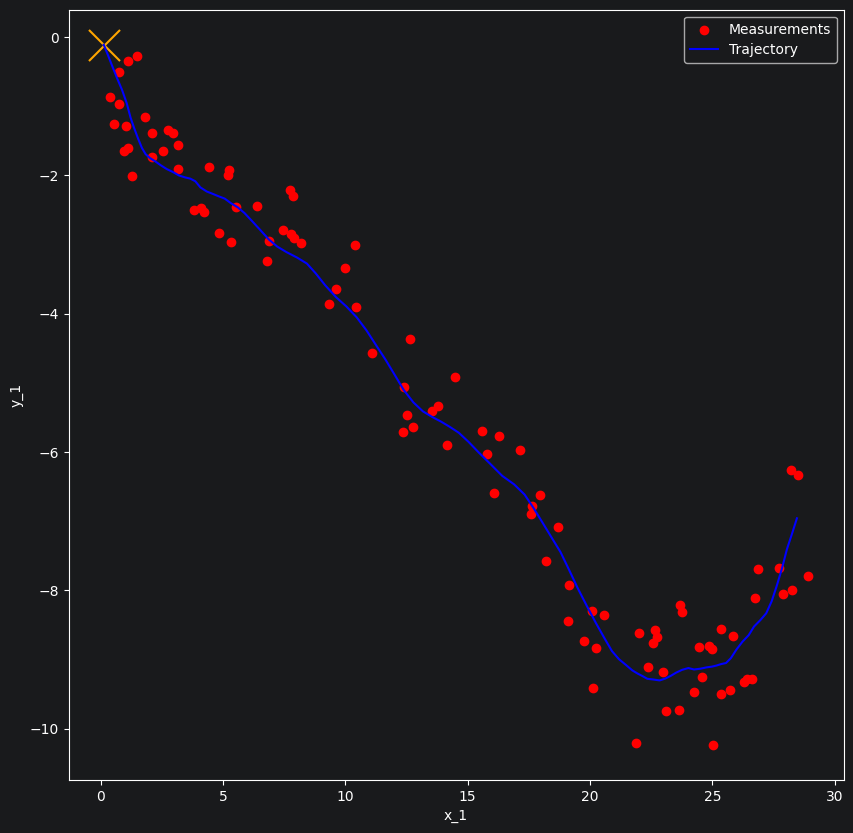

In [351]:
plot_trajectory(observations, states, "Trajectory")

## Kalman Filter

In [352]:
m_0 = np.array([0, 0, 0, 0])
P_0 = np.array([[1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [0, 0, 0, 1]]) * 10

In [353]:
def kalman_predict(m, P, A, Q):
    """ This is the Kalman filter prediction step """
    m = A @ m
    P = A @ P @ A.T + Q
    return m, P

def kalman_update(m, P, H, R, y):
    """ This is the Kalman filter update step """
    S = H @ P @ H.T + R
    K = linalg.solve(S, H @ P.T, assume_a="pos").T
    # More efficient and stable way of computing K = P @ H.T @ linalg.inv(S)
    # This also leverages the fact that S is known to be a positive definite matrix (assume_a="pos")
    m = m + K @ (y - H @ m)
    P = P - K @ S @ K.T
    return m, P

def kalman_distance(m, P, H, R, y):
    """ This is the Mahalanobis distance between the prediction and the measurement """
    v = y - H @ m
    S = H @ P @ H.T + R
    return np.dot(linalg.solve(S, v, assume_a="pos"), v)

def kalman_filter(m_0, P_0, A, Q, H, R, ys):
    M = m_0.shape[-1]
    steps, N = observations.shape

    kf_m = np.empty((steps, M))
    kf_P = np.empty((steps, M, M))

    m = m_0
    P = P_0

    for i in range(steps):
        y = ys[i]
        m, P = kalman_predict(m, P, A, Q)

#        d = kalman_distance(m, P, H, R, y)
#        print(f"Distance at step {i}: {d}")

        m, P = kalman_update(m, P, H, R, y)


        kf_m[i] = m
        kf_P[i] = P
    return kf_m, kf_P

In [354]:
kf_m, kf_P = kalman_filter(m_0, P_0, A, Q, H, R, observations)

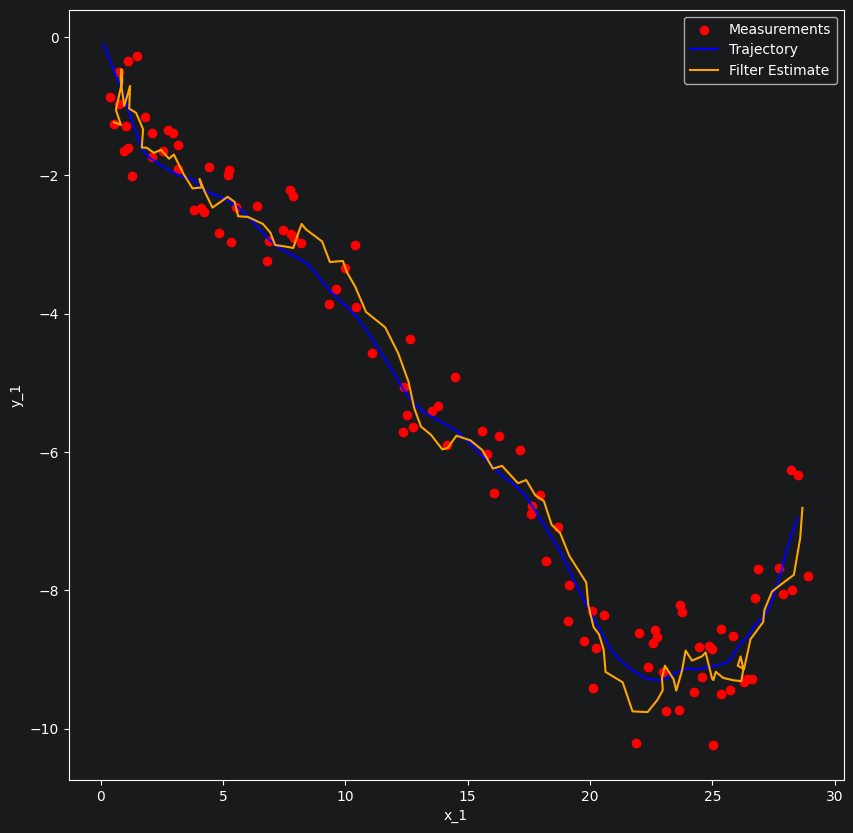

In [355]:
plot_trajectory(observations, states, "Trajectory", kf_m, "Filter Estimate")

In [356]:
rmse_raw = rmse(states[:, :2], observations)
rmse_kf = rmse(kf_m[:, :2], states[:, :2])
print(f"RAW RMSE: {rmse_raw}")
print(f"KF RMSE: {rmse_kf}")

RAW RMSE: 0.7000040825632761
KF RMSE: 0.41743954760084656


## Multiple Target Tracking

We now extend the single-target 2D Kalman filter to a multiple-target tracking scenario.
A configurable number of targets with distinct initial states are simulated using
the same motion model. At each time step, measurements from all targets are present,
but with unknown data association — the tracker does not know which measurement
belongs to which target.


### Simulating Multiple Targets

We define a configurable number of initial states (position and velocity) and
generate independent trajectories for each target using the same linear-Gaussian
state space model (matrices `A`, `Q`, `H`, `R`). The observations are then
combined at each time step in scrambled order to simulate the unknown data
association problem. Change `n_targets` below to experiment with different
numbers of targets.


In [357]:
# Number of targets — change this value to scale the simulation
n_targets = 4
radius = n_targets * 1.2

# Generate diverse initial states spread around a circle
# Each target starts at a different position with a velocity roughly
# perpendicular to the position vector (tangential to the circle)
rd.seed(42)
x_0_targets = []
for i in range(n_targets):
    angle = 2 * np.pi * i / n_targets
    px = radius * np.cos(angle)
    py = radius * np.sin(angle)
    vx = np.cos(angle + np.pi / 2)
    vy = np.sin(angle + np.pi / 2)
    x_0_targets.append(np.array([px, py, vx, vy]))

# Generate independent trajectories
all_states_list = []       # list of (steps, M) arrays, one per target
all_observations_list = []  # list of (steps, N) arrays, one per target

for i in range(n_targets):
    states_i, obs_i = generate_ssm(x_0_targets[i], A, Q, H, R, steps)
    all_states_list.append(states_i)
    all_observations_list.append(obs_i)

# Combine observations: at each time step, stack all measurements and shuffle
# This removes target labels, simulating unknown data association
combined_observations = []  # list of (n_targets, N) arrays, one per step
for t in range(steps):
    meas_at_t = np.vstack([all_observations_list[i][t] for i in range(n_targets)])
    np.random.shuffle(meas_at_t)
    combined_observations.append(meas_at_t)

print(f"Generated {n_targets} targets, {steps} time steps each.")
print(f"Combined observations shape per step: {combined_observations[0].shape}")


Generated 4 targets, 100 time steps each.
Combined observations shape per step: (4, 2)


### Visualizing All Targets

The following plot shows the true trajectories of all targets and their
measurements, with each target in a different colour.


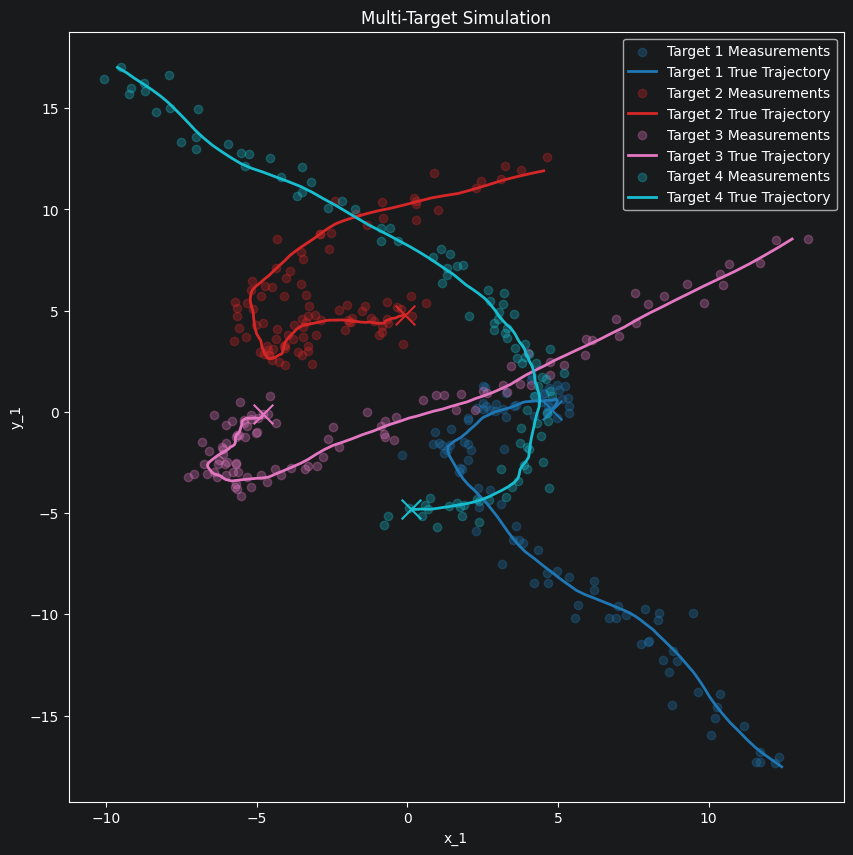

In [358]:
def plot_multitarget(all_states, all_obs, title="Multi-Target Simulation"):
    """Plots all target trajectories and measurements on the same axes."""
    n = len(all_states)
    fig, ax = plt.subplots(figsize=(10, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, n))
    for i, (states, obs) in enumerate(zip(all_states, all_obs)):
        ax.scatter(obs[:, 0], obs[:, 1], marker='o', color=colors[i],
                   alpha=0.3, label=f'Target {i+1} Measurements')
        ax.plot(states[:, 0], states[:, 1], color=colors[i],
                label=f'Target {i+1} True Trajectory', linewidth=2)
        ax.scatter(states[0, 0], states[0, 1], marker='x', color=colors[i], s=200)
    ax.legend()
    ax.set_xlabel('x_1')
    ax.set_ylabel('y_1')
    ax.set_title(title)
    plt.show()

plot_multitarget(all_states_list, all_observations_list)


## Nearest Neighbor Multi-Target Tracker

We implement a Nearest Neighbor (NN) based multi-target tracking algorithm.
The approach runs one Kalman filter per target (each with its own state and
covariance) and, at each time step:

1. **Predict** the next state for each track.
2. Compute the Mahalanobis distance between each track's prediction and each
   measurement.
3. Apply **chi-squared gating** to reject unlikely measurement-to-track associations.
4. Perform a **greedy nearest-neighbor assignment** of measurements to tracks,
   ensuring each measurement is assigned to at most one track.
5. For tracks with an assigned measurement, run the **Kalman update**.
   For tracks without any gated measurement, perform **coasting**
   (keep the prediction as the estimate).


#### Chi-Squared Gating

The squared Mahalanobis distance between a track prediction and a measurement
follows a $\chi^2$ distribution with $N$ degrees of freedom (where $N$ is the
measurement dimension). We use the 95% confidence threshold to define a validation
gate: any measurement with distance exceeding the threshold is considered too
unlikely and is rejected. Only measurements falling within the gate are eligible
for association with a given track.


In [359]:
from scipy.stats import chi2

# 95% confidence gate: squared Mahalanobis distance threshold
gate_threshold = chi2.ppf(0.95, df=N)
print(f"Gate threshold (95% confidence, df = {N}): {gate_threshold:.4f}")


Gate threshold (95% confidence, df = 2): 5.9915


#### Nearest Neighbor Assignment

The assignment algorithm works as follows:

1. Compute a cost matrix $C_{t,m}$ where each entry is the squared Mahalanobis
   distance between track $t$'s prediction and measurement $m$.
2. Apply gating: set $C_{t,m} = \infty$ if the distance exceeds the
   $\chi^2$ threshold.
3. Collect all valid (finite-cost) track-measurement pairs, sort them by
   ascending cost.
4. Greedily assign: iterate through the sorted pairs and assign a measurement
   to a track only if both are still unassigned. This ensures each measurement
   is associated to at most one track.
5. Tracks with no valid measurement in the gate receive an assignment of $-1$
   and will coast (prediction only, no update).


In [360]:
def nearest_neighbor_assignment(ms, Ps, H, R, measurements, gate_threshold):
    """
    Performs greedy Nearest Neighbor measurement-to-track assignment with
    Mahalanobis distance gating.

    Parameters
    ----------
    ms : list of (M,) ndarray
        Predicted state means for each track.
    Ps : list of (M, M) ndarray
        Predicted state covariances for each track.
    H : (N, M) ndarray
        Observation model matrix.
    R : (N, N) ndarray
        Measurement noise covariance.
    measurements : (K, N) ndarray or None
        Measurements at the current time step. If None or empty, all tracks coast.
    gate_threshold : float
        Chi-squared threshold; measurements with Mahalanobis distance
        exceeding this value are ignored.

    Returns
    -------
    assignments : list of int
        assignments[t] = m if measurement m is assigned to track t,
        or -1 if the track should coast (no measurement in gate or
        all measurements already taken by other tracks).
    """
    n_tracks = len(ms)

    if measurements is None or len(measurements) == 0:
        return [-1] * n_tracks

    n_meas = len(measurements)

    # Compute cost matrix: squared Mahalanobis distance
    costs = np.full((n_tracks, n_meas), np.inf)
    for t in range(n_tracks):
        for m in range(n_meas):
            d2 = kalman_distance(ms[t], Ps[t], H, R, measurements[m])
            if d2 < gate_threshold:
                costs[t, m] = d2

    # Greedy NN assignment: pick smallest valid cost first, ensure
    # each measurement is assigned to at most one track.
    assignments = [-1] * n_tracks
    assigned_meas = set()

    # Build list of all valid (cost, track, meas) triples, sorted by cost
    valid_pairs = [(costs[t, m], t, m)
                   for t in range(n_tracks)
                   for m in range(n_meas)
                   if costs[t, m] < np.inf]
    valid_pairs.sort(key=lambda x: x[0])

    for _, t, m in valid_pairs:
        if m not in assigned_meas and assignments[t] == -1:
            assignments[t] = m
            assigned_meas.add(m)

    return assignments


#### NN Multi-Target Kalman Filter

The main filter loop runs a separate Kalman filter instance for each target.
At each time step:

1. **Predict** the next state for every track using `kalman_predict`.
2. Run **nearest neighbor association** to match measurements to tracks.
3. **Update** tracks that received a measurement via `kalman_update`.
   **Coast** tracks with no assignment (keep prediction as estimate).
4. Store the estimates for analysis and visualization.


In [361]:
def nn_multitarget_filter(m_0_list, P_0_list, A, Q, H, R,
                         combined_obs, gate_threshold):
    """
    Runs independent Kalman filters for multiple targets with NN data
    association at each step.

    Parameters
    ----------
    m_0_list : list of (M,) ndarray
        Initial state means, one per track.
    P_0_list : list of (M, M) ndarray
        Initial state covariances, one per track.
    A, Q, H, R : ndarray
        State-space model matrices.
    combined_obs : list of (K, N) ndarray
        Measurements at each time step (shuffled, unknown identity).
    gate_threshold : float
        Chi-squared threshold for measurement gating.

    Returns
    -------
    estimates : list of (steps, M) ndarray
        Estimated state trajectories for each track.
    covariances : list of (steps, M, M) ndarray
        Filter covariance at each step for each track.
    """
    n_tracks = len(m_0_list)
    steps = len(combined_obs)
    M = m_0_list[0].shape[-1]

    # Storage for estimates and covariances
    estimates = [np.empty((steps, M)) for _ in range(n_tracks)]
    covariances = [np.empty((steps, M, M)) for _ in range(n_tracks)]

    # Initialise track states
    ms = [np.copy(m_0_list[i]) for i in range(n_tracks)]
    Ps = [np.copy(P_0_list[i]) for i in range(n_tracks)]

    for i in range(steps):
        # --- Predict step for all tracks ---
        for t in range(n_tracks):
            ms[t], Ps[t] = kalman_predict(ms[t], Ps[t], A, Q)

        # --- NN measurement-to-track association ---
        y_at_step = combined_obs[i]
        assignments = nearest_neighbor_assignment(
            ms, Ps, H, R, y_at_step, gate_threshold
        )

        # --- Update or coast each track ---
        for t in range(n_tracks):
            if assignments[t] >= 0:
                # Measurement found in gate -> Kalman update
                y_matched = y_at_step[assignments[t]]
                ms[t], Ps[t] = kalman_update(ms[t], Ps[t], H, R, y_matched)
            # else: coasting — keep the prediction as current estimate

            estimates[t][i] = ms[t]
            covariances[t][i] = Ps[t]

    return estimates, covariances


### Running the Multi-Target Tracker

We run the NN multi-target Kalman filter on the combined (shuffled) measurements.

A realistic strategy for track initialisation is **measurement-driven**:
each measurement from the first frame creates a new track, initialised at
the observed position with zero initial velocity and the prior covariance
`P_0`. Tracks are then propagated and updated on subsequent frames.

This is more faithful to how a real multi-target tracker operates: tracks
are born directly from sensor detections — no prior guess about their
initial positions is needed.


In [362]:
# --- Measurement-driven track initialisation ---
# Use the first frame to spawn one track per measurement.
# Each track is born at the measurement position with unknown velocity.
first_frame = combined_observations[0]  # (n_targets, N)

m_0_list = []
P_0_list = []
for i in range(n_targets):
    m_i = m_0.copy()
    m_i[0] = first_frame[i, 0]
    m_i[1] = first_frame[i, 1]
    m_0_list.append(m_i)
    P_0_list.append(P_0.copy())

print(f"Spawned {n_targets} tracks from frame-0 measurements.")

# --- Run filter on remaining frames (1 .. steps-1) ---
nn_estimates, nn_covariances = nn_multitarget_filter(
    m_0_list, P_0_list, A, Q, H, R,
    combined_observations[1:], gate_threshold
)

# Prepend the initialisation states as step-0 estimates
for i in range(n_targets):
    nn_estimates[i] = np.vstack([m_0_list[i].reshape(1, -1), nn_estimates[i]])

print("NN Multi-Target Kalman Filter completed.")


Spawned 4 tracks from frame-0 measurements.
NN Multi-Target Kalman Filter completed.


### Visualizing NN Tracking Results

The following plots show the **raw tracker output** — one subplot per track.

In a real multi-target tracking system:
- Measurements arrive from the sensor with **no identity labels**.
- The tracker creates one track per measurement (or maintains existing tracks).
- Each track gets an **arbitrary ID** — it simply follows whatever
  measurement trajectory it latches onto.
- There is **no notion of matching tracks to true targets** because
  ground truth is not available in production.

What matters is that all measurements are consistently associated to
some track and that each track follows a coherent trajectory over time.
Track IDs are just labels — Track 4 may be following physical object A,
Track 1 may be following object B; the tracker does not know or care.

The ground truth plots above () are shown for reference
only — they are not available during real operations.


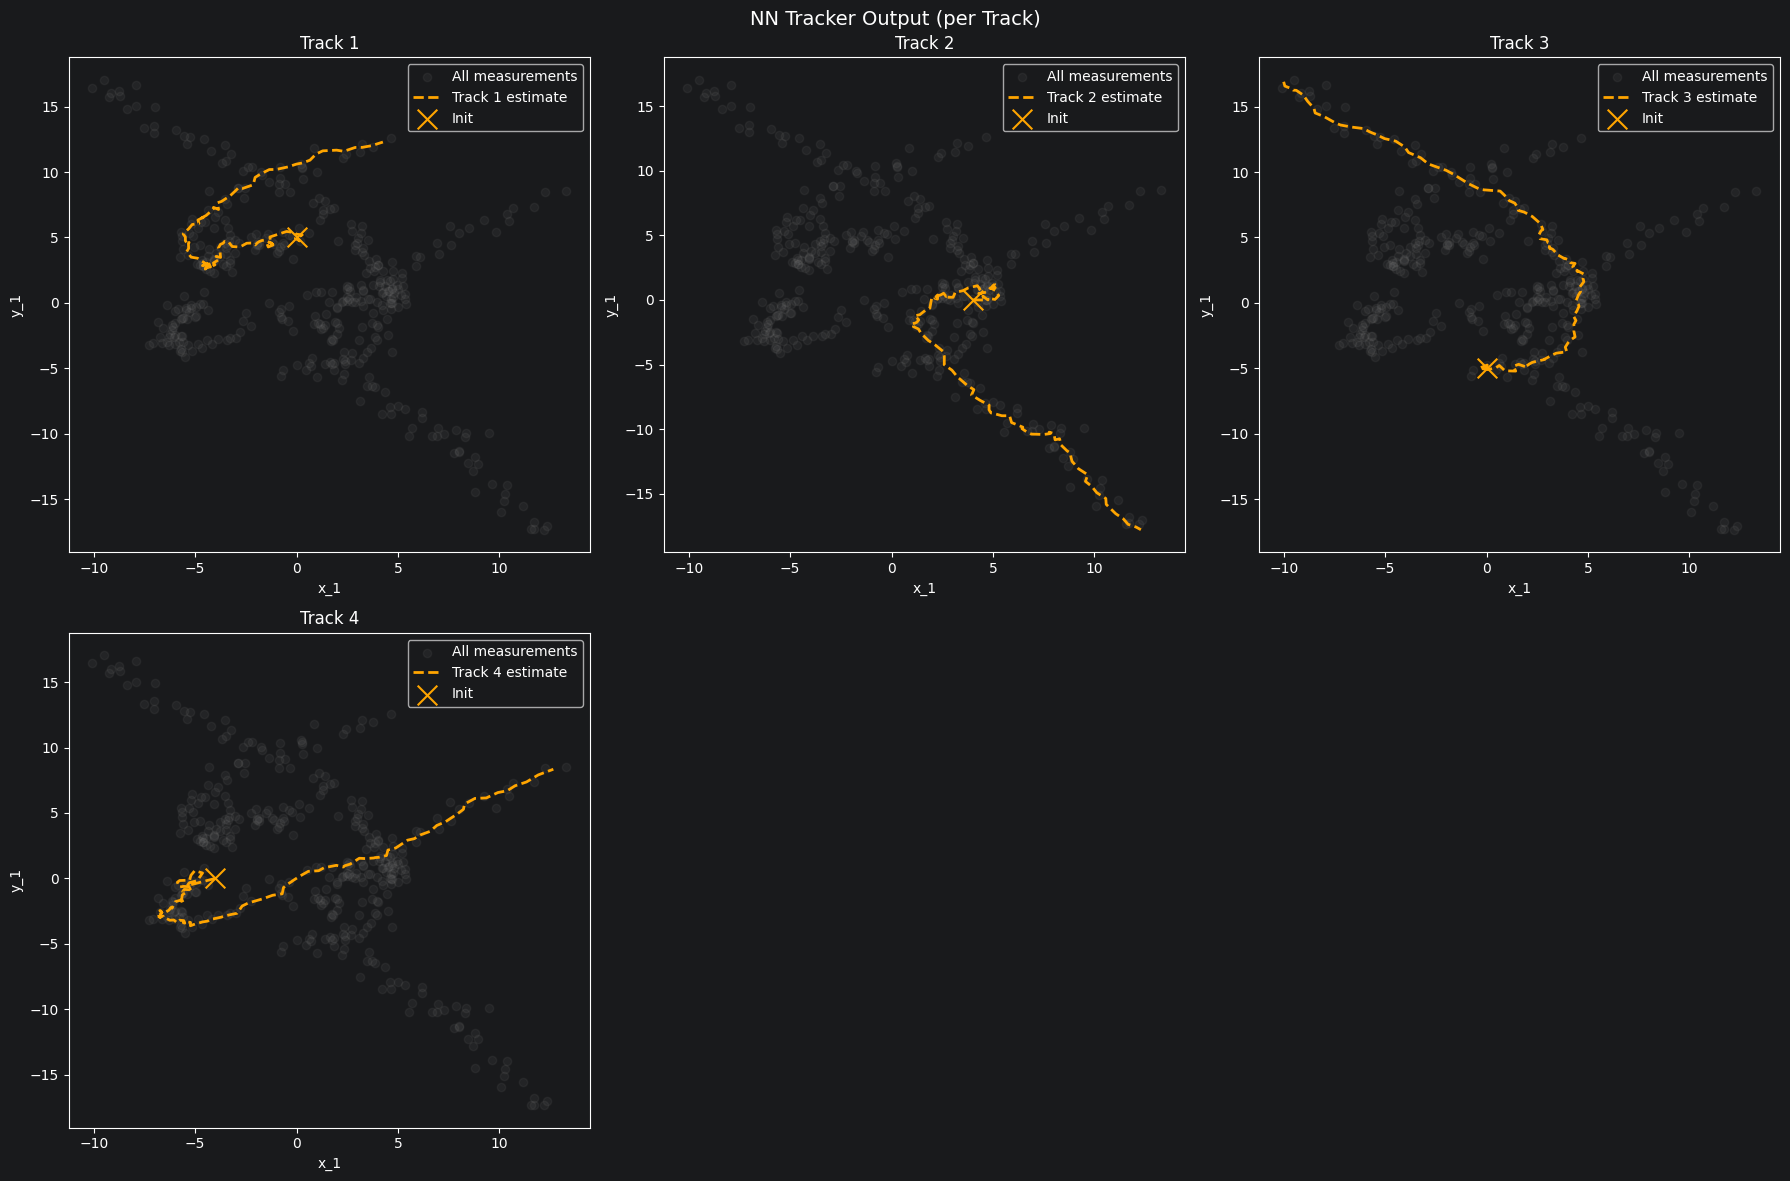

In [363]:
def plot_tracker_output(estimates, combined_obs,
                        title="NN Tracker Output (per Track)"):
    """Plots each track's estimate without any ground-truth matching."""
    n = len(estimates)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    # Collect all measurements for background scatter
    all_meas = np.vstack(combined_obs)

    for i in range(n):
        ax = axes[i]
        # Light scatter of all measurements (the tracker saw them all)
        ax.scatter(all_meas[:, 0], all_meas[:, 1],
                   marker="o", color="grey", alpha=0.1,
                   label="All measurements")
        # This track's estimated trajectory
        ax.plot(estimates[i][:, 0], estimates[i][:, 1],
                color="orange", linestyle="--", linewidth=2,
                label=f"Track {i+1} estimate")
        ax.scatter(estimates[i][0, 0], estimates[i][0, 1],
                   marker="x", color="orange", s=200, label="Init")
        ax.set_xlabel("x_1")
        ax.set_ylabel("y_1")
        ax.set_title(f"Track {i+1}")
        ax.legend()

    # Hide unused subplots
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_tracker_output(nn_estimates, combined_observations)


### RMSE per Target

We compute the Root Mean Squared Error between:
- The raw measurements and the true positions ("Raw RMSE")
- The NN filter estimates and the true positions ("NN KF RMSE")

**Note:** since tracks are born from anonymous measurements, we first **match**
each track to its closest ground-truth target (by final-position proximity).
This matching is for evaluation only — a real tracker has no access to
ground truth.


In [364]:
print("=".center(50, "="))
print("RMSE per target (position only)")
print("=".center(50, "="))

# --- Track-to-target matching ---
# Tracks were born from anonymous measurements, so we need to determine
# which track ended up following which true target.  Matching is done
# by greedy assignment based on final position proximity.
final_true = np.array([all_states_list[i][-1, :2] for i in range(n_targets)])
final_est = np.array([nn_estimates[i][-1, :2] for i in range(n_targets)])

target_to_track = {}
used_tracks = set()
pairs = sorted([(np.linalg.norm(final_est[t] - final_true[m]), t, m)
                for t in range(n_targets) for m in range(n_targets)])
for d, t, m in pairs:
    if t not in used_tracks and m not in target_to_track:
        target_to_track[m] = t
        used_tracks.add(t)

for m in range(n_targets):
    t = target_to_track[m]
    true_pos = all_states_list[m][:, :2]
    raw_pos = all_observations_list[m]
    est_pos = nn_estimates[t][:, :2]

    raw_rmse = rmse(true_pos, raw_pos)
    kf_rmse = rmse(true_pos, est_pos)

    print(f"Target {m+1}:")
    print(f"  Raw RMSE:    {raw_rmse:.4f}")
    print(f"  NN KF RMSE:  {kf_rmse:.4f}")
    print(f"  (Matched to Track {t+1})")


RMSE per target (position only)
Target 1:
  Raw RMSE:    0.7473
  NN KF RMSE:  0.4884
  (Matched to Track 2)
Target 2:
  Raw RMSE:    0.7316
  NN KF RMSE:  0.4090
  (Matched to Track 1)
Target 3:
  Raw RMSE:    0.6886
  NN KF RMSE:  0.4516
  (Matched to Track 4)
Target 4:
  Raw RMSE:    0.6352
  NN KF RMSE:  0.5517
  (Matched to Track 3)
